# BBO Function 1 — Part 2 reflection analysis

This notebook is for the **first 2D unknown function**.

It is designed to help answer the Part 2 reflection prompts:
- which evaluated inputs behaved like support vectors or boundary points;
- how surrogate gradients change with the inputs;
- how classification framing separates “good” and “bad” outputs;
- whether linear regression, SVM, or neural networks are most useful;
- which variables influence the surrogate most;
- whether the neural network captures nonlinear patterns better than simpler models.

Assumption: this BBO objective is being **minimised**.


## Version 1: GP regression + minimisation expected improvement

Use this version for query choice and for explaining exploitation/exploration.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load original function 1 data.
# Run this notebook from the same folder where initial_data/function_1 exists.
input_data = np.load('../../data/initial_data/function_1/initial_inputs.npy')
output_data = np.load('../../data/initial_data/function_1/initial_outputs.npy')

# Add your latest evaluated point here.
# You said the new input is (0.5, 0.5). Replace NEW_OUTPUT with the portal output.
NEW_POINT = np.array([
    [0.759048, 0.965375],
    [0.714910, 0.858164],
    [0.5, 0.5],
])

NEW_OUTPUT = np.array([
    0.29645067004988124,
    0.4598605438093154,
    2.6752879910742468e-9
])

if NEW_OUTPUT is not None:
    input_data = np.vstack([input_data, NEW_POINT])
    output_data = np.append(output_data, NEW_OUTPUT)

df = pd.DataFrame(input_data, columns=['x1', 'x2'])
df['y'] = output_data
df['log_abs_y'] = np.log(np.abs(output_data) + 1e-300)
df['rank_min'] = df['y'].rank(method='min', ascending=True).astype(int)

print(df.sort_values('y').to_string(index=True))
print("\nBest point so far:")
print(df.loc[df['y'].idxmin()])


<>:14: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?
<>:14: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?
/var/folders/2c/2l9498855s14s62mtrzw6wz80000gn/T/ipykernel_59373/3392558172.py:14: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?
  [0.714910, 0.858164]
/var/folders/2c/2l9498855s14s62mtrzw6wz80000gn/T/ipykernel_59373/3392558172.py:14: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?
  [0.714910, 0.858164]
/var/folders/2c/2l9498855s14s62mtrzw6wz80000gn/T/ipykernel_59373/3392558172.py:14: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?
  [0.714910, 0.858164]
/var/folders/2c/2l9498855s14s62mtrzw6wz80000gn/T/ipykernel_59373/3392558172.py:14: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?
  [0.714910, 0.

TypeError: list indices must be integers or slices, not tuple

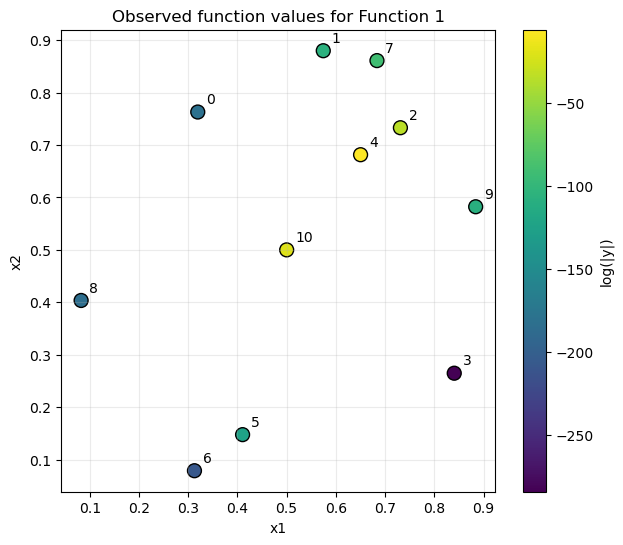

In [7]:

plt.figure(figsize=(7, 6))
sc = plt.scatter(df['x1'], df['x2'], c=df['log_abs_y'], s=100, edgecolors='black')
plt.colorbar(sc, label='log(|y|)')
for i, row in df.iterrows():
    plt.annotate(str(i), (row['x1'], row['x2']), xytext=(6, 6), textcoords='offset points')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Observed function values for Function 1')
plt.grid(alpha=0.25)
plt.show()


In [9]:

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from scipy.stats import norm

X = input_data
y = output_data

kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(2), length_scale_bounds=(1e-2, 10), nu=2.5) + WhiteKernel(noise_level=1e-10, noise_level_bounds=(1e-12, 1e-3))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True, random_state=42)
gp.fit(X, y)

print("Learned kernel:")
print(gp.kernel_)

def expected_improvement_min(Xcand, model, y_best, xi=0.01):
    mu, sigma = model.predict(Xcand, return_std=True)
    sigma = np.maximum(sigma, 1e-12)
    improvement = y_best - mu - xi
    Z = improvement / sigma
    return improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

rng = np.random.default_rng(42)
candidates = rng.random((20000, 2))
ei = expected_improvement_min(candidates, gp, y_best=np.min(y), xi=0.01)

best_idx = np.argmax(ei)
best_next = candidates[best_idx]
pred_mean, pred_std = gp.predict(best_next.reshape(1, -1), return_std=True)

print(f"Suggested next query: [{best_next[0]:.6f}, {best_next[1]:.6f}]")
print(f"Predicted mean: {pred_mean[0]:.6e}")
print(f"Predicted std:  {pred_std[0]:.6e}")
print(f"EI score:       {ei[best_idx]:.6e}")


Learned kernel:
1.01**2 * Matern(length_scale=[0.0162, 10], nu=2.5) + WhiteKernel(noise_level=3.43e-11)
Suggested next query: [0.624478, 0.451183]
Predicted mean: -1.162840e-03
Predicted std:  1.016722e-03
EI score:       7.929799e-39


/Users/andriy/miniconda3/envs/appenv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


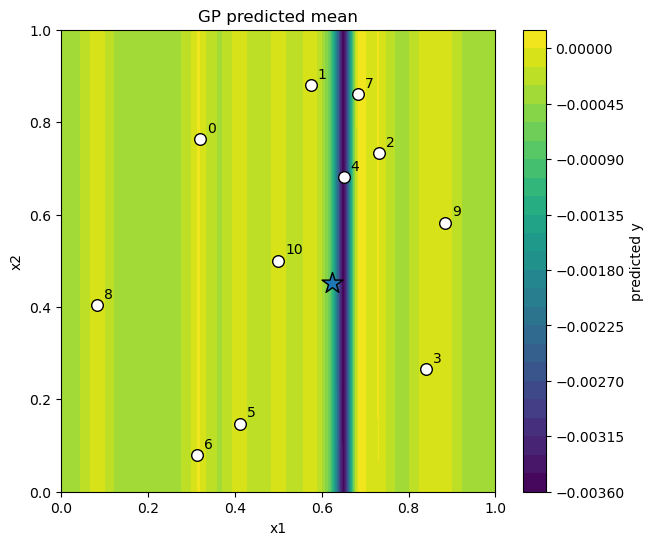

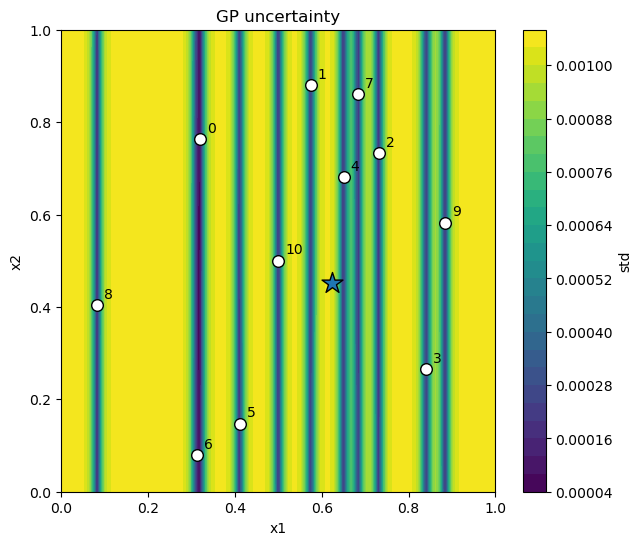

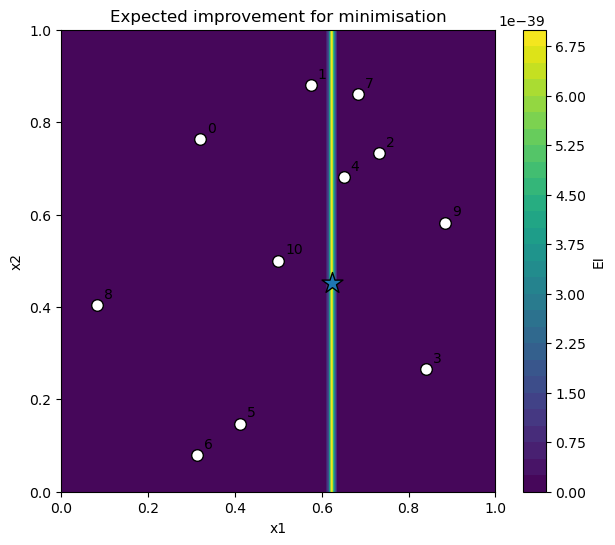

In [10]:

# Visualise GP mean and uncertainty.
grid_n = 160
xx, yy = np.meshgrid(np.linspace(0, 1, grid_n), np.linspace(0, 1, grid_n))
grid = np.column_stack([xx.ravel(), yy.ravel()])
mu, std = gp.predict(grid, return_std=True)
mu_grid = mu.reshape(grid_n, grid_n)
std_grid = std.reshape(grid_n, grid_n)
ei_grid = expected_improvement_min(grid, gp, np.min(y), xi=0.01).reshape(grid_n, grid_n)

for title, z, label in [
    ("GP predicted mean", mu_grid, "predicted y"),
    ("GP uncertainty", std_grid, "std"),
    ("Expected improvement for minimisation", ei_grid, "EI")
]:
    plt.figure(figsize=(7, 6))
    cs = plt.contourf(xx, yy, z, levels=30)
    plt.colorbar(cs, label=label)
    plt.scatter(X[:,0], X[:,1], c='white', edgecolors='black', s=70)
    plt.scatter(best_next[0], best_next[1], marker='*', s=250, edgecolors='black')
    for i, (a,b) in enumerate(X):
        plt.annotate(str(i), (a,b), xytext=(5,5), textcoords='offset points')
    plt.xlabel('x1'); plt.ylabel('x2'); plt.title(title)
    plt.show()


## Reflection evidence from this version

Use this notebook to say:

The GP surrogate gave me a smooth approximation of the unknown 2D function and an uncertainty estimate. I used expected improvement for minimisation, so the proposed query balances points where the predicted output is low with points where uncertainty is still high. This helps justify the fourth-round query as not purely greedy: it is guided by both the current best region and unexplored regions.